In [2]:
import pandas as pd

blr_level1_results = pd.DataFrame({
    "Prior Standard Deviation": [0.1, 0.5, 1.0, 2.0, 5.0],
    "Mean ROC-AUC": [0.912333, 0.912432, 0.912426, 0.912551, 0.912528],
    "Standard ROC-AUC": [0.000786, 0.000750, 0.000776, 0.000827, 0.000816]
})

display(blr_level1_results)

,Prior Standard Deviation,Mean ROC-AUC,Standard ROC-AUC
0,0.1,0.912333,0.000786
1,0.5,0.912432,0.000750
2,1.0,0.912426,0.000776
3,2.0,0.912551,0.000827
4,5.0,0.912528,0.000816


In [3]:
import pandas as pd

blr_level2_results = pd.DataFrame({
    "Prior Standard Deviation": [1.5, 1.8, 2.0, 2.2, 2.5],
    "Mean ROC-AUC": [0.912586, 0.912603, 0.912627, 0.912470, 0.912511],
    "Standard ROC-AUC": [0.000719, 0.000804, 0.000752, 0.000769, 0.000729]
})

display(blr_level2_results)

,Prior Standard Deviation,Mean ROC-AUC,Standard ROC-AUC
0,1.5,0.912586,0.000719
1,1.8,0.912603,0.000804
2,2.0,0.912627,0.000752
3,2.2,0.912470,0.000769
4,2.5,0.912511,0.000729


In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *

import pymc as pm
import pytensor.tensor as pt

In [3]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train distribution:")
print(pd.Series(y_train).value_counts())

Train shape: (759384, 23)
Test shape: (118799, 23)
Train distribution:
1.0    379692
0.0    379692
Name: count, dtype: int64


In [4]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("int32")
y_test = y_test.astype("int32")

In [5]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

print("Tuning Shape:", X_tune.shape)

print("\nTuning Distribution:")
print(pd.Series(y_tune).value_counts())

Tuning Shape: (100000, 23)

Tuning Distribution:
1    50000
0    50000
Name: count, dtype: int64


In [6]:
level1_prior_sd_values = [0.1, 0.5, 1.0, 2.0, 5.0]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
def train_blr_and_predict(X_train_fold, y_train_fold, X_val_fold, prior_sd, advi_iter=10000, draws=500):
    n_features = X_train_fold.shape[1]

    with pm.Model():

        alpha = pm.Normal(
            "alpha",
            mu=0,
            sigma=prior_sd
        )

        beta = pm.Normal(
            "beta",
            mu=0,
            sigma=prior_sd,
            shape=n_features
        )

        logits = alpha + pt.dot(X_train_fold, beta)

        p = pm.Deterministic(
            "p",
            pm.math.sigmoid(logits)
        )

        pm.Bernoulli(
            "y_obs",
            p=p,
            observed=y_train_fold
        )

        approx = pm.fit(
            n=advi_iter,
            method="advi",
            progressbar=False
        )

        trace = approx.sample(
            draws=draws
        )

    alpha_samples = trace.posterior["alpha"].values.reshape(-1)
    beta_samples = trace.posterior["beta"].values.reshape(-1, X_val_fold.shape[1])

    logits_val = alpha_samples[:, None] + beta_samples @ X_val_fold.T
    probabilities_val = 1 / (1 + np.exp(-logits_val))

    y_val_prob = probabilities_val.mean(axis=0)

    return y_val_prob

In [10]:
level1_results = []

for prior_sd in level1_prior_sd_values:
    fold_auc_scores = []

    print(f"\nTesting prior_sd = {prior_sd}")

    for fold, (train_index, val_index) in enumerate(skf.split(X_tune, y_tune), start=1):
        print(f"\nFold {fold}/5")

        X_fold_train = X_tune.iloc[train_index].values.astype("float32")
        y_fold_train = y_tune[train_index].astype("int32")

        X_fold_val = X_tune.iloc[val_index].values.astype("float32")
        y_fold_val = y_tune[val_index].astype("int32")

        start_time = time.time()

        y_val_prob = train_blr_and_predict(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            prior_sd=prior_sd,
            advi_iter=10000,
            draws=500
        )

        fold_auc = roc_auc_score(y_fold_val, y_val_prob)
        fold_auc_scores.append(fold_auc)

        fold_time = time.time() - start_time

        print(f"Fold ROC-AUC: {fold_auc:.6f}")
        print(f"Fold Time: {fold_time:.2f} seconds")

    mean_auc = np.mean(fold_auc_scores)
    std_auc = np.std(fold_auc_scores)

    level1_results.append({
        "prior_sd": prior_sd,
        "Mean ROC-AUC": mean_auc,
        "Std ROC-AUC": std_auc
    })

    print(f"\nprior_sd={prior_sd} | Mean ROC-AUC={mean_auc:.6f} | Std={std_auc:.6f}")

level1_results_df = pd.DataFrame(level1_results)
level1_results_df


Testing prior_sd = 0.1

Fold 1/5


Finished [100%]: Average Loss = 33,741


Fold ROC-AUC: 0.911020
Fold Time: 170.67 seconds

Fold 2/5


Finished [100%]: Average Loss = 33,767


Fold ROC-AUC: 0.913430
Fold Time: 155.62 seconds

Fold 3/5


...

Finished [100%]: Average Loss = 32,836


Fold ROC-AUC: 0.913211
Fold Time: 156.81 seconds

Fold 5/5


Finished [100%]: Average Loss = 32,942


Fold ROC-AUC: 0.912643
Fold Time: 155.60 seconds

prior_sd=5.0 | Mean ROC-AUC=0.912528 | Std=0.000816


,prior_sd,Mean ROC-AUC,Std ROC-AUC
0,0.1,0.912333,0.000786
1,0.5,0.912432,0.000750
2,1.0,0.912426,0.000776
3,2.0,0.912551,0.000827
4,5.0,0.912528,0.000816


In [11]:
best_prior_sd_level1 = float(
    level1_results_df.sort_values(
        by="Mean ROC-AUC",
        ascending=False
    ).iloc[0]["prior_sd"]
)

print("Best prior_sd from Level 1:", best_prior_sd_level1)

Best prior_sd from Level 1: 2.0


In [12]:
if best_prior_sd_level1 == 0.1:
    level2_prior_sd_values = [0.05, 0.08, 0.1, 0.2, 0.3]
elif best_prior_sd_level1 == 0.5:
    level2_prior_sd_values = [0.3, 0.4, 0.5, 0.6, 0.8]
elif best_prior_sd_level1 == 1.0:
    level2_prior_sd_values = [0.8, 0.9, 1.0, 1.2, 1.5]
elif best_prior_sd_level1 == 2.0:
    level2_prior_sd_values = [1.5, 1.8, 2.0, 2.2, 2.5]
else:
    level2_prior_sd_values = [3.0, 4.0, 5.0, 6.0, 8.0]

print("Level 2 prior_sd values:", level2_prior_sd_values)

Level 2 prior_sd values: [1.5, 1.8, 2.0, 2.2, 2.5]


In [13]:
level2_results = []

for prior_sd in level2_prior_sd_values:
    fold_auc_scores = []

    print(f"\nTesting prior_sd = {prior_sd}")

    for fold, (train_index, val_index) in enumerate(skf.split(X_tune, y_tune), start=1):
        print(f"\nFold {fold}/5")

        X_fold_train = X_tune.iloc[train_index].values.astype("float32")
        y_fold_train = y_tune[train_index].astype("int32")

        X_fold_val = X_tune.iloc[val_index].values.astype("float32")
        y_fold_val = y_tune[val_index].astype("int32")

        start_time = time.time()

        y_val_prob = train_blr_and_predict(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            prior_sd=prior_sd,
            advi_iter=10000,
            draws=500
        )

        fold_auc = roc_auc_score(y_fold_val, y_val_prob)
        fold_auc_scores.append(fold_auc)

        fold_time = time.time() - start_time

        print(f"Fold ROC-AUC: {fold_auc:.6f}")
        print(f"Fold Time: {fold_time:.2f} seconds")

    mean_auc = np.mean(fold_auc_scores)
    std_auc = np.std(fold_auc_scores)

    level2_results.append({
        "prior_sd": prior_sd,
        "Mean ROC-AUC": mean_auc,
        "Std ROC-AUC": std_auc
    })

    print(f"\nprior_sd={prior_sd} | Mean ROC-AUC={mean_auc:.6f} | Std={std_auc:.6f}")

level2_results_df = pd.DataFrame(level2_results)
level2_results_df


Testing prior_sd = 1.5

Fold 1/5


Finished [100%]: Average Loss = 32,795


Fold ROC-AUC: 0.911384
Fold Time: 156.43 seconds

Fold 2/5


Finished [100%]: Average Loss = 32,863


Fold ROC-AUC: 0.913371
Fold Time: 155.19 seconds

Fold 3/5


...

Finished [100%]: Average Loss = 32,832


Fold ROC-AUC: 0.913032
Fold Time: 155.68 seconds

Fold 5/5


Finished [100%]: Average Loss = 32,808


Fold ROC-AUC: 0.912481
Fold Time: 154.82 seconds

prior_sd=2.5 | Mean ROC-AUC=0.912511 | Std=0.000729


,prior_sd,Mean ROC-AUC,Std ROC-AUC
0,1.5,0.912586,0.000719
1,1.8,0.912603,0.000804
2,2.0,0.912627,0.000752
3,2.2,0.912470,0.000769
4,2.5,0.912511,0.000729


In [14]:
best_prior_sd = float(
    level2_results_df.sort_values(
        by="Mean ROC-AUC",
        ascending=False
    ).iloc[0]["prior_sd"]
)

print("Final Best prior_sd:", best_prior_sd)

Final Best prior_sd: 2.0


In [16]:
X_train_np = X_train.values.astype("float32")
y_train_np = y_train.astype("int32")

n_features = X_train_np.shape[1]

start_time = time.time()

with pm.Model() as final_blr_model:

    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=best_prior_sd
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=best_prior_sd,
        shape=n_features
    )

    logits = alpha + pt.dot(X_train_np, beta)

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logits)
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y_train_np
    )

    approx = pm.fit(
        n=20000,
        method="advi",
        progressbar=False
    )

    final_blr_trace = approx.sample(
        draws=1000,
        random_seed=42
    )

blr_train_time = time.time() - start_time

print(f"Final BLR Training Time: {blr_train_time:.2f} seconds")

Finished [100%]: Average Loss = 2.719e+05


Final BLR Training Time: 2951.61 seconds


In [17]:
alpha_samples = final_blr_trace.posterior["alpha"].values.reshape(-1)
beta_samples = final_blr_trace.posterior["beta"].values.reshape(-1, X_test.shape[1])

alpha_mean = alpha_samples.mean()
beta_mean = beta_samples.mean(axis=0)

X_test_np = X_test.values.astype("float32")

logits_test = alpha_mean + X_test_np @ beta_mean
y_prob_blr = 1 / (1 + np.exp(-logits_test))

y_prob_blr = np.clip(y_prob_blr, 1e-15, 1 - 1e-15)
y_pred_blr = (y_prob_blr >= 0.5).astype(int)

print("Prediction completed.")

Prediction completed.


In [18]:
blr_accuracy = accuracy_score(y_test, y_pred_blr)
blr_precision = precision_score(y_test, y_pred_blr)
blr_recall = recall_score(y_test, y_pred_blr)
blr_f1 = f1_score(y_test, y_pred_blr)
blr_auc = roc_auc_score(y_test, y_prob_blr)
blr_logloss = log_loss(y_test, y_prob_blr)
blr_brier = brier_score_loss(y_test, y_prob_blr)

blr_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Log Loss",
        "Brier Score",
        "Training Time"
    ],
    "BLR": [
        blr_accuracy,
        blr_precision,
        blr_recall,
        blr_f1,
        blr_auc,
        blr_logloss,
        blr_brier,
        blr_train_time
    ]
})

blr_results

,Metric,BLR
0,Accuracy,0.863669
1,Precision,0.936836
2,Recall,0.889106
3,F1 Score,0.912347
4,ROC-AUC,0.910788
5,Log Loss,0.345304
6,Brier Score,0.104640
7,Training Time,2951.610178


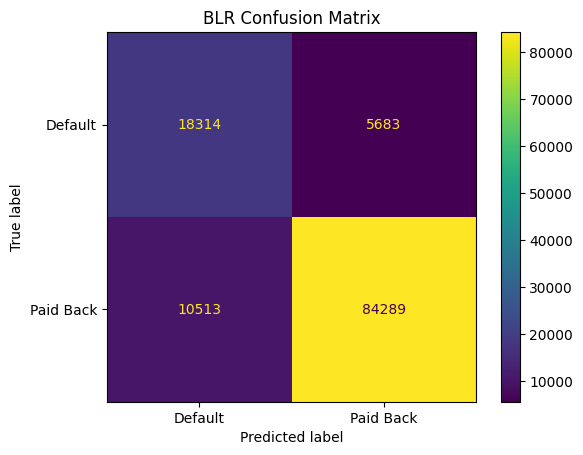

In [19]:
cm = confusion_matrix(y_test, y_pred_blr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Default", "Paid Back"]
)

disp.plot()
plt.title("BLR Confusion Matrix")
plt.show()

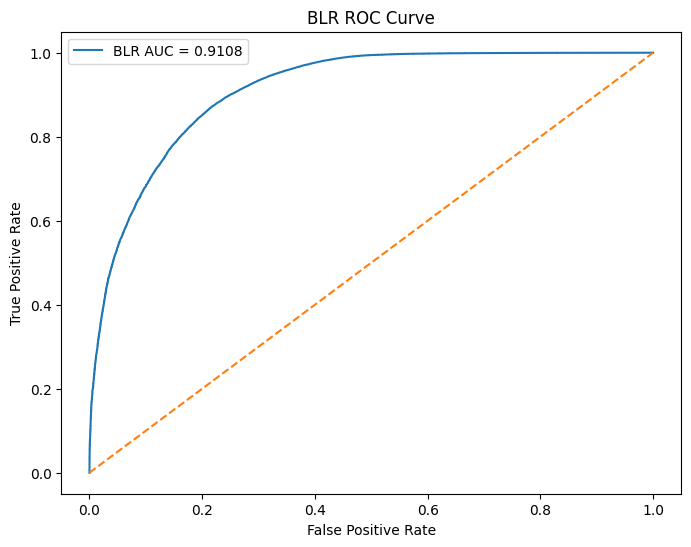

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_blr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"BLR AUC = {blr_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BLR ROC Curve")
plt.legend()
plt.show()

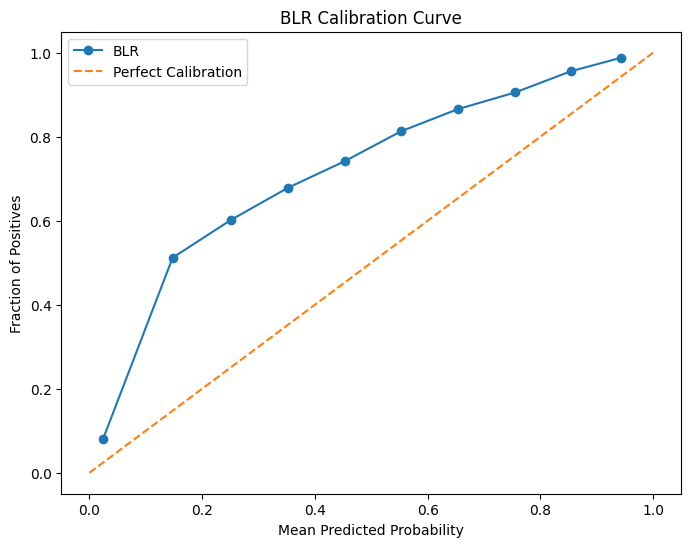

In [21]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_blr,
    n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="BLR"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("BLR Calibration Curve")
plt.legend()
plt.show()

In [ ]:
blr_model_data = {
    "alpha_mean": alpha_mean,
    "beta_mean": beta_mean,
    "alpha_samples": alpha_samples,
    "beta_samples": beta_samples,
    "best_prior_sd": best_prior_sd,
    "columns": X_train.columns.tolist()
}

joblib.dump(
    blr_model_data,
    "../models/blr_model.pkl"
)

blr_best_parameters = pd.DataFrame({
    "Search Level": ["Level 1", "Level 2"],

    "Best prior_sd": [
        best_prior_sd_level1,
        best_prior_sd
    ],

    "Best Mean ROC-AUC": [
        level1_results_df.loc[
            level1_results_df["Mean ROC-AUC"].idxmax(),
            "Mean ROC-AUC"
        ],
        level2_results_df.loc[
            level2_results_df["Mean ROC-AUC"].idxmax(),
            "Mean ROC-AUC"
        ]
    ],

    "Best Std ROC-AUC": [
        level1_results_df.loc[
            level1_results_df["Mean ROC-AUC"].idxmax(),
            "Std ROC-AUC"
        ],
        level2_results_df.loc[
            level2_results_df["Mean ROC-AUC"].idxmax(),
            "Std ROC-AUC"
        ]
    ]
})

blr_best_parameters.to_csv(
    "../results/blr_best_parameters.csv",
    index=False
)

blr_results.to_csv(
    "../results/blr_evaluation_results.csv",
    index=False
)

print("BLR model and results saved successfully.")

BLR model and results saved successfully.
